# Imports and Reading Data

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split,KFold,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")


In [35]:
file_path = "ankarahouseprices_withcoordinates.csv"
df = pd.read_csv(file_path)

# Data Understanding

In [36]:
df.shape

(1474, 9)

In [37]:
df.head()

,Unnamed: 0,County,Neighborhood,Room,Saloon,m2,Price,latitude,longitude
0,0,Yenimahalle,Yeni Batı Mahallesi,1.0,1,55,35000,39.974463,32.696714
1,1,Etimesgut,Süvari Mahallesi,3.0,1,125,23500,39.948701,32.645555
2,2,Çankaya,Prof. Dr. Ahmet Taner Kışlalı Mahallesi,4.0,1,195,75000,39.873919,32.687875
3,3,Çankaya,Erzurum Mahallesi,2.0,1,80,17000,39.930957,32.871750
4,4,Çankaya,Konutkent Mahallesi,1.0,0,45,25000,39.877841,32.667996


In [38]:
df.columns

Index(['Unnamed: 0', 'County', 'Neighborhood', 'Room', 'Saloon', 'm2', 'Price',
       'latitude', 'longitude'],
      dtype='object')

In [39]:
df.dtypes

Unnamed: 0        int64
County           object
Neighborhood     object
Room            float64
Saloon            int64
m2                int64
Price             int64
latitude        float64
longitude       float64
dtype: object

In [40]:
df.describe()

,Unnamed: 0,Room,Saloon,m2,Price,latitude,longitude
count,1474.000000,1474.000000,1474.000000,1474.000000,1.474000e+03,1474.000000,1474.000000
mean,736.500000,2.540706,0.985753,114.550882,3.294472e+04,39.924715,32.765686
std,425.651461,0.957713,0.144369,44.044157,1.066302e+05,0.104533,0.175777
min,0.000000,1.000000,0.000000,25.000000,1.750000e+03,38.929482,31.907131
25%,368.250000,2.000000,1.000000,90.000000,2.050000e+04,39.890955,32.687875
50%,736.500000,3.000000,1.000000,115.000000,2.500000e+04,39.940276,32.826113
75%,1104.750000,3.000000,1.000000,130.000000,3.450000e+04,39.979960,32.866557
max,1473.000000,7.000000,2.000000,450.000000,3.650000e+06,40.469711,33.550079


# Data Preparition

In [41]:
df.isna().sum()

Unnamed: 0      0
County          0
Neighborhood    0
Room            0
Saloon          0
m2              0
Price           0
latitude        0
longitude       0
dtype: int64

In [42]:
df.loc[df.duplicated()]

,Unnamed: 0,County,Neighborhood,Room,Saloon,m2,Price,latitude,longitude


In [43]:
df["County"].value_counts()

County
Çankaya            408
Keçiören           262
Yenimahalle        160
Etimesgut          138
Mamak              122
Gölbaşı            105
Sincan             103
Altındağ            56
Polatlı             48
Pursaklar           31
Çubuk               14
Akyurt              10
Beypazarı            8
Kahramankazan        5
Şereflikoçhisar      3
Kızılcahamam         1
Name: count, dtype: int64

In [44]:
#Cleaning counties that is not enough to train 
df = df[df["County"].map(df["County"].value_counts()) >= 10]
df["County"].value_counts()

County
Çankaya        408
Keçiören       262
Yenimahalle    160
Etimesgut      138
Mamak          122
Gölbaşı        105
Sincan         103
Altındağ        56
Polatlı         48
Pursaklar       31
Çubuk           14
Akyurt          10
Name: count, dtype: int64

Text(0, 0.5, 'Count')

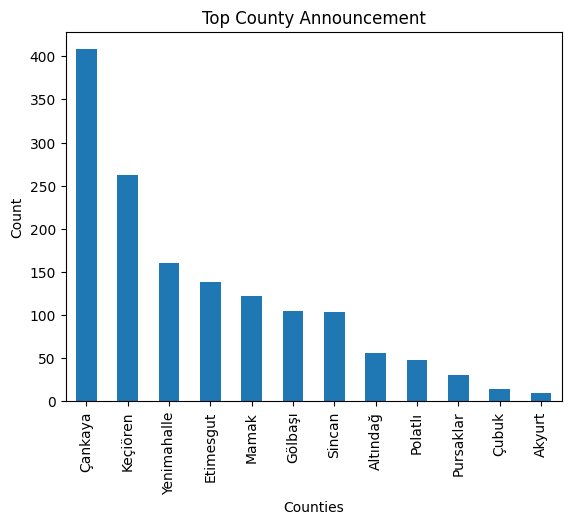

In [45]:
ax = df['County'].value_counts() \
    .head(20) \
    .plot(kind='bar', title='Top County Announcement')
ax.set_xlabel('Counties')
ax.set_ylabel('Count')

In [46]:
df['Neighborhood'].value_counts()

# The model cannot learn from neighbourhoods because there are only four data points for each neighbourhood.
# This is not sufficient to train a model.

Neighborhood
İncek Mahallesi            35
Aşağı Eğlence Mahallesi    28
Yaşamkent Mahallesi        28
Ayvalı Mahallesi           28
Bahçelievler Mahallesi     26
                           ..
Çarşı Mahallesi             1
Bayındır Mahallesi          1
Yeniçağ Mahallesi           1
Yenice Mahallesi            1
Topraklık Mahallesi         1
Name: count, Length: 301, dtype: int64

Text(0, 0.5, 'Count')

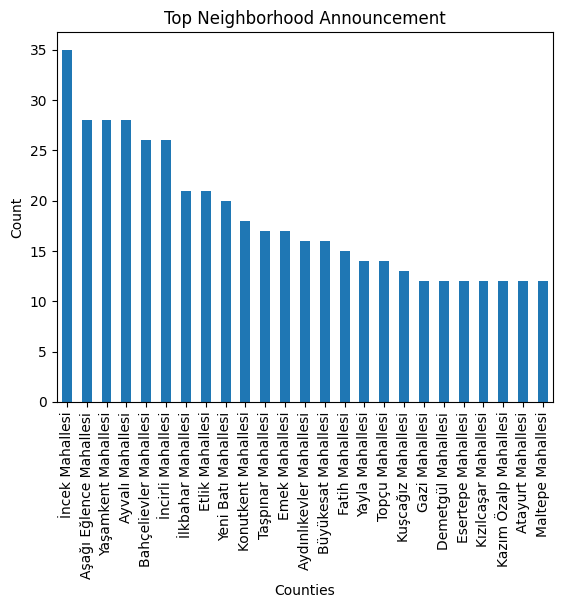

In [47]:
ax = df['Neighborhood'].value_counts() \
    .head(25) \
    .plot(kind='bar', title='Top Neighborhood Announcement')
ax.set_xlabel('Counties')
ax.set_ylabel('Count')

<Axes: >

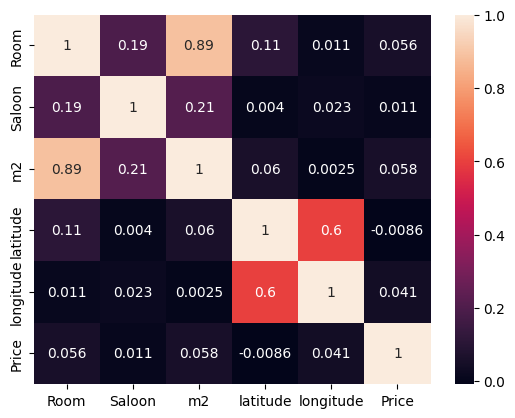

In [48]:
df_corr = df[["Room","Saloon","m2","latitude","longitude","Price"]].corr()
sns.heatmap(df_corr, annot=True)

# Outlier Detection & Cleaning

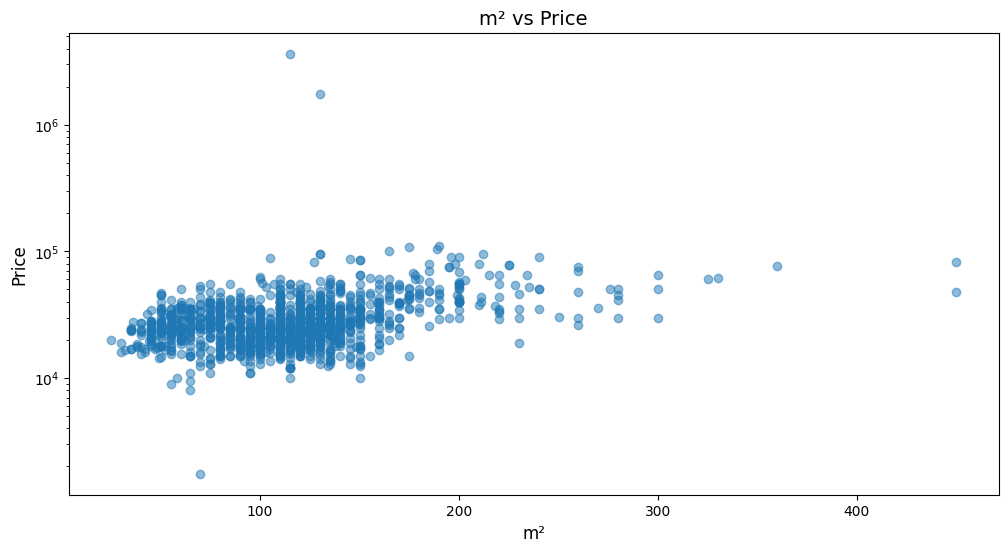

In [49]:
plt.figure(figsize = [12,6])
plt.scatter(df["m2"],df["Price"],alpha = 0.5)
plt.yscale("log")
plt.title("m² vs Price", fontsize=14)
plt.xlabel("m²", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

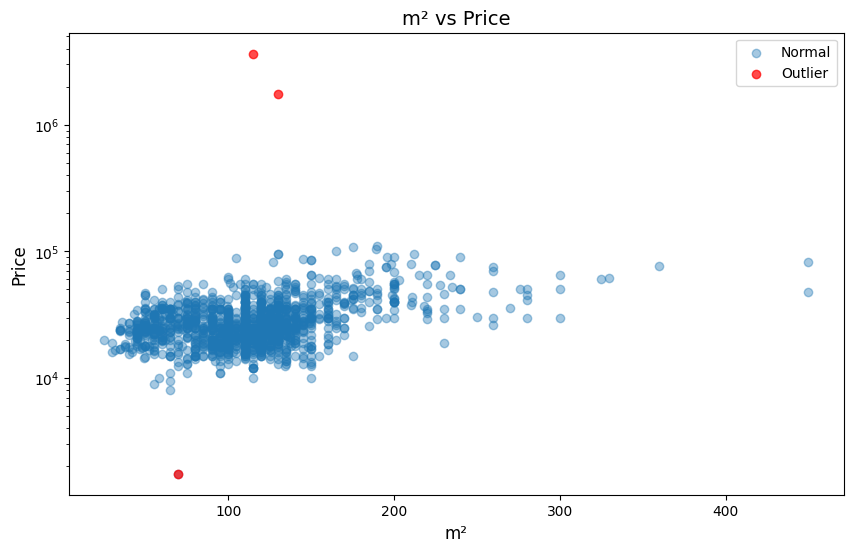

Outlier Records:
      m2    Price  Room  Saloon  County              Neighborhood
154  130  1750000   3.0       1  Sincan  Mareşal Çakmak Mahallesi
702   70     1750   1.0       1  Sincan         Atatürk Mahallesi
861  115  3650000   3.0       1   Mamak        Bayındır Mahallesi


In [50]:
max_threshold_price = 150_000  
min_threshold_price = 5_000

outliers = df[(df["Price"] > max_threshold_price) | (df["Price"] < min_threshold_price)]
normal = df[df["Price"] <= max_threshold_price]

plt.figure(figsize=(10,6))
plt.scatter(normal["m2"], normal["Price"], alpha=0.4, label="Normal")
plt.scatter(outliers["m2"], outliers["Price"], color="red", alpha=0.7, label="Outlier")
plt.title("m² vs Price", fontsize=14)
plt.yscale("log")
plt.xlabel("m²", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()
plt.show()

print("Outlier Records:")
print(outliers[["m2", "Price", "Room", "Saloon", "County", "Neighborhood"]])


In [51]:
df = df.drop(outliers.index)

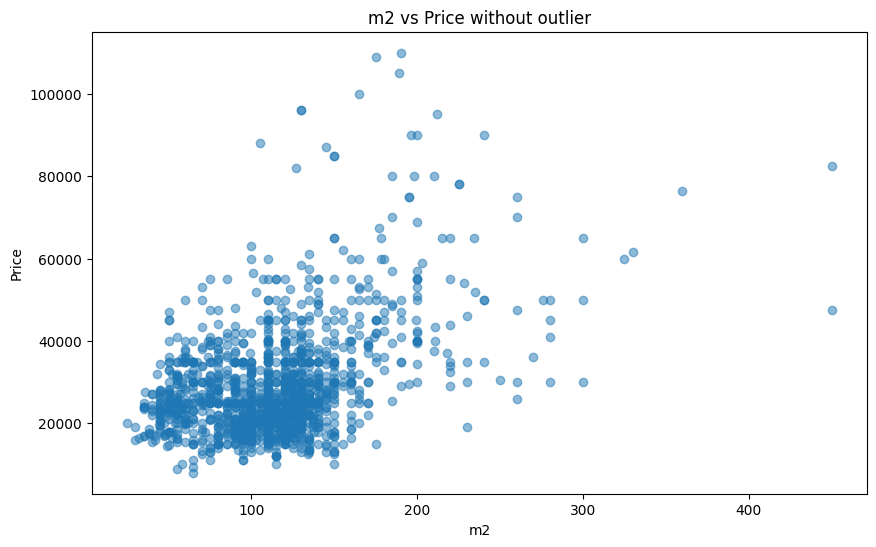

In [52]:
plt.figure(figsize = [10,6])
plt.scatter(df["m2"],df["Price"],alpha = 0.5)
plt.title("m2 vs Price without outlier")
plt.xlabel("m2")
plt.ylabel("Price")
plt.show()

# Feature Engineering

In [53]:
df["Price per m2"] = df["Price"] / df["m2"]

df

,Unnamed: 0,County,Neighborhood,Room,Saloon,m2,Price,latitude,longitude,Price per m2
0,0,Yenimahalle,Yeni Batı Mahallesi,1.0,1,55,35000,39.974463,32.696714,636.363636
1,1,Etimesgut,Süvari Mahallesi,3.0,1,125,23500,39.948701,32.645555,188.000000
2,2,Çankaya,Prof. Dr. Ahmet Taner Kışlalı Mahallesi,4.0,1,195,75000,39.873919,32.687875,384.615385
3,3,Çankaya,Erzurum Mahallesi,2.0,1,80,17000,39.930957,32.871750,212.500000
4,4,Çankaya,Konutkent Mahallesi,1.0,0,45,25000,39.877841,32.667996,555.555556
...,...,...,...,...,...,...,...,...,...,...
1469,1469,Gölbaşı,Bahçelievler Mahallesi,2.0,1,80,26000,39.789888,32.807271,325.000000
1470,1470,Mamak,Diriliş Mahallesi,2.0,1,90,27750,39.951407,32.901735,308.333333
1471,1471,Gölbaşı,Hacılar Mahallesi,2.0,1,68,26500,39.771655,32.722639,389.705882
1472,1472,Gölbaşı,İncek Mahallesi,1.0,1,47,20000,39.807543,32.697350,425.531915


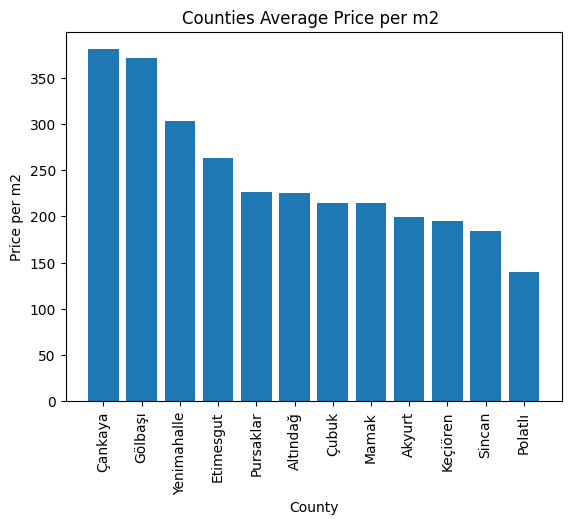

In [54]:
county_average = df.groupby("County")["Price per m2"].mean().reset_index()
county_average.sort_values("Price per m2",inplace = True,ascending = False)

plt.figure()
plt.bar(county_average["County"],county_average["Price per m2"])
plt.title("Counties Average Price per m2 ")
plt.xlabel("County")
plt.xticks(rotation = 90)
plt.ylabel("Price per m2")
plt.show()

In [55]:
df["total_room"] = df["Room"] + df["Saloon"]
df

,Unnamed: 0,County,Neighborhood,Room,Saloon,m2,Price,latitude,longitude,Price per m2,total_room
0,0,Yenimahalle,Yeni Batı Mahallesi,1.0,1,55,35000,39.974463,32.696714,636.363636,2.0
1,1,Etimesgut,Süvari Mahallesi,3.0,1,125,23500,39.948701,32.645555,188.000000,4.0
2,2,Çankaya,Prof. Dr. Ahmet Taner Kışlalı Mahallesi,4.0,1,195,75000,39.873919,32.687875,384.615385,5.0
3,3,Çankaya,Erzurum Mahallesi,2.0,1,80,17000,39.930957,32.871750,212.500000,3.0
4,4,Çankaya,Konutkent Mahallesi,1.0,0,45,25000,39.877841,32.667996,555.555556,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1469,1469,Gölbaşı,Bahçelievler Mahallesi,2.0,1,80,26000,39.789888,32.807271,325.000000,3.0
1470,1470,Mamak,Diriliş Mahallesi,2.0,1,90,27750,39.951407,32.901735,308.333333,3.0
1471,1471,Gölbaşı,Hacılar Mahallesi,2.0,1,68,26500,39.771655,32.722639,389.705882,3.0
1472,1472,Gölbaşı,İncek Mahallesi,1.0,1,47,20000,39.807543,32.697350,425.531915,2.0


In [56]:
kmeans = KMeans(n_clusters=10, random_state=42,n_init=10)
df['cluster_id'] = kmeans.fit_predict(df[['latitude', 'longitude']])
df

,Unnamed: 0,County,Neighborhood,Room,Saloon,m2,Price,latitude,longitude,Price per m2,total_room,cluster_id
0,0,Yenimahalle,Yeni Batı Mahallesi,1.0,1,55,35000,39.974463,32.696714,636.363636,2.0,7
1,1,Etimesgut,Süvari Mahallesi,3.0,1,125,23500,39.948701,32.645555,188.000000,4.0,7
2,2,Çankaya,Prof. Dr. Ahmet Taner Kışlalı Mahallesi,4.0,1,195,75000,39.873919,32.687875,384.615385,5.0,4
3,3,Çankaya,Erzurum Mahallesi,2.0,1,80,17000,39.930957,32.871750,212.500000,3.0,5
4,4,Çankaya,Konutkent Mahallesi,1.0,0,45,25000,39.877841,32.667996,555.555556,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1469,1469,Gölbaşı,Bahçelievler Mahallesi,2.0,1,80,26000,39.789888,32.807271,325.000000,3.0,0
1470,1470,Mamak,Diriliş Mahallesi,2.0,1,90,27750,39.951407,32.901735,308.333333,3.0,5
1471,1471,Gölbaşı,Hacılar Mahallesi,2.0,1,68,26500,39.771655,32.722639,389.705882,3.0,4
1472,1472,Gölbaşı,İncek Mahallesi,1.0,1,47,20000,39.807543,32.697350,425.531915,2.0,4


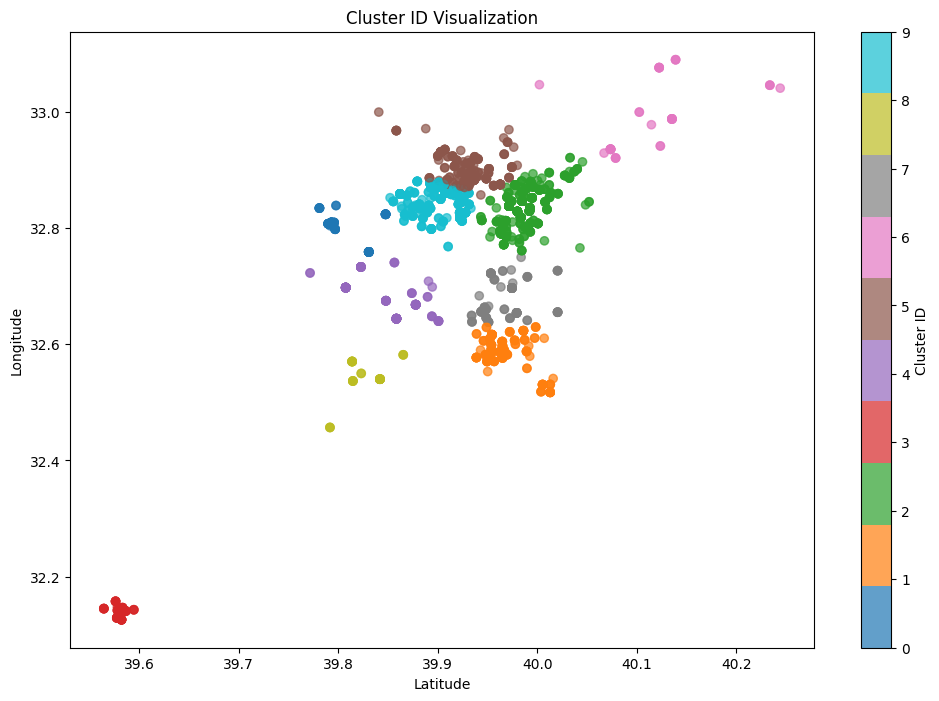

In [57]:
plt.figure(figsize = [12,8])
scatter = plt.scatter(df["latitude"],df["longitude"],alpha = 0.7,c = df["cluster_id"],cmap = "tab10")
plt.title("Cluster ID Visualization")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.colorbar(scatter,label = "Cluster ID")
plt.show()

# Data Preprocessing with One-Hot Encoding


**I cleaned up the neighbourhood column because there is too much diversity between neighbourhoods.
If I use this feature, the machine learning model cannot be trained.**


In [58]:
df = df.drop(["Neighborhood","Price per m2"],axis = 1)
df

,Unnamed: 0,County,Room,Saloon,m2,Price,latitude,longitude,total_room,cluster_id
0,0,Yenimahalle,1.0,1,55,35000,39.974463,32.696714,2.0,7
1,1,Etimesgut,3.0,1,125,23500,39.948701,32.645555,4.0,7
2,2,Çankaya,4.0,1,195,75000,39.873919,32.687875,5.0,4
3,3,Çankaya,2.0,1,80,17000,39.930957,32.871750,3.0,5
4,4,Çankaya,1.0,0,45,25000,39.877841,32.667996,1.0,4
...,...,...,...,...,...,...,...,...,...,...
1469,1469,Gölbaşı,2.0,1,80,26000,39.789888,32.807271,3.0,0
1470,1470,Mamak,2.0,1,90,27750,39.951407,32.901735,3.0,5
1471,1471,Gölbaşı,2.0,1,68,26500,39.771655,32.722639,3.0,4
1472,1472,Gölbaşı,1.0,1,47,20000,39.807543,32.697350,2.0,4


In [59]:
df = pd.get_dummies(df,columns = ["County"],drop_first = True)

<Axes: >

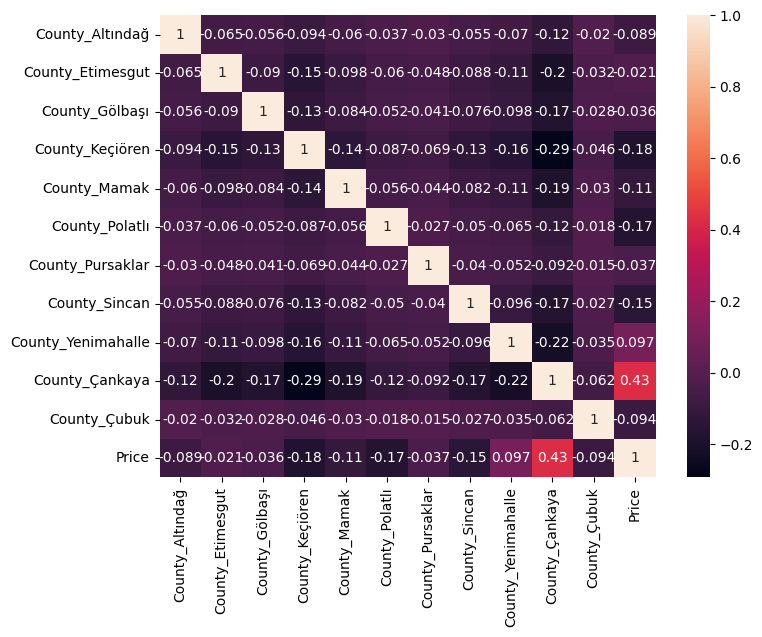

In [60]:
df_corr = df[['County_Altındağ', 'County_Etimesgut', 'County_Gölbaşı',
       'County_Keçiören', 'County_Mamak', 'County_Polatlı', 'County_Pursaklar',
       'County_Sincan', 'County_Yenimahalle', 'County_Çankaya',
       'County_Çubuk',"Price"]].corr()

plt.figure(figsize = [8,6])
sns.heatmap(df_corr, annot=True)

# Model Prediction with Train/Test Split

In [61]:
df.shape

(1454, 20)

In [62]:
X = df.drop(["Price"],axis = 1)
y = df["Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)


model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("R2 Score: ",r2)
print("Root Mean Squared Error: ",rmse)

R2 Score:  0.48961315044512754
Root Mean Squared Error:  8559.04915447633


# Model Prediction with K-Fold Cross Validation

Linear Regression Prediction Scores 

R2 Score:  0.4896131504451269
RMSE:  8559.049154476334
R2 Score:  0.5636454886627328
RMSE:  8632.701175973745
R2 Score:  0.4679968448062213
RMSE:  9887.651837629435
R2 Score:  0.4266678117040582
RMSE:  8859.456451020986
R2 Score:  0.4421531531237626
RMSE:  10717.101697243907


Ridge Prediction Scores 

R2 Score:  0.4886505273374192
RMSE:  8567.116816558064
R2 Score:  0.5650110901918919
RMSE:  8619.18227383084
R2 Score:  0.46888880195187854
RMSE:  9879.359535822075
R2 Score:  0.42632250185315845
RMSE:  8862.124011948485
R2 Score:  0.4466428283508779
RMSE:  10673.887766306061


Lasso Prediction Scores 

R2 Score:  0.49003246133092737
RMSE:  8555.532567098664
R2 Score:  0.5646142641615233
RMSE:  8623.112875398972
R2 Score:  0.4679649903018348
RMSE:  9887.94785235334
R2 Score:  0.42691593787072835
RMSE:  8857.539149930206
R2 Score:  0.4434440720802121
RMSE:  10704.694239026025


Random Forest Prediction Scores 

R2 Score:  0.6691346026197973
RMSE:  689

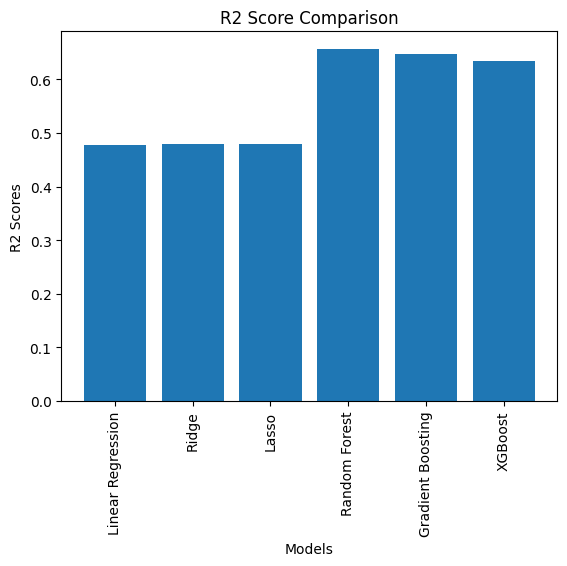

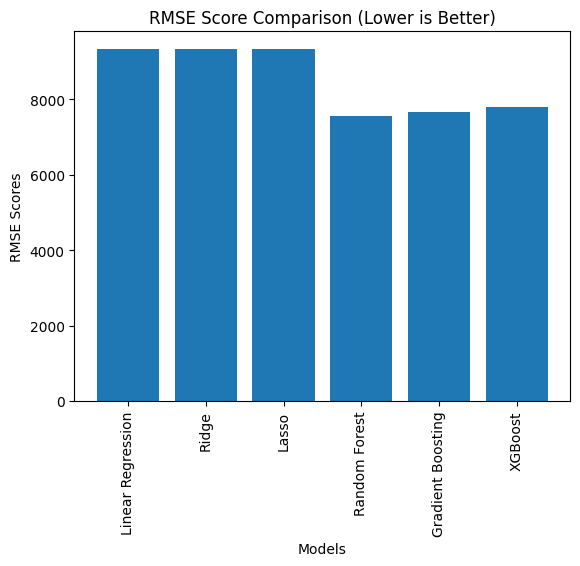

In [63]:
kf = KFold(n_splits=5,shuffle = True,random_state = 42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost" : XGBRegressor()
}

results_r2 = {}
results_rmse = {}


for name,model in models.items():

    r2_scores = []
    rmse_scores = []
    
    print(f"{name} Prediction Scores \n")
    
    for train_index,test_index in kf.split(X):
    
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
    
        
        r2 = r2_score(y_test,y_pred)
        rmse = np.sqrt(mean_squared_error(y_test,y_pred))

        r2_scores.append(r2)
        rmse_scores.append(rmse)
        
        
        print("R2 Score: ",r2)
        print("RMSE: ",rmse)

    print("\n")

    results_r2[name] = np.mean(r2_scores)
    results_rmse[name] = np.mean(rmse_scores)
            

df_r2 = pd.DataFrame(list(results_r2.items()), columns=["Model", "R2"])
df_rmse = pd.DataFrame(list(results_rmse.items()), columns=["Model", "RMSE"])

plt.figure()
plt.bar(df_r2["Model"],df_r2["R2"])
plt.title("R2 Score Comparison")
plt.xticks(rotation = 90)
plt.xlabel("Models")
plt.ylabel("R2 Scores")
plt.show()


plt.bar(df_rmse["Model"],df_rmse["RMSE"])
plt.title("RMSE Score Comparison (Lower is Better)")
plt.xticks(rotation = 90)
plt.xlabel("Models")
plt.ylabel("RMSE Scores")
plt.show()

# HyperParameter Tuning of RandomForest

In [64]:
model = RandomForestRegressor()

kf = KFold(n_splits=5,shuffle = True,random_state = 42)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    estimator = model,
    param_grid = param_grid,
    cv = kf,
    scoring = "neg_mean_squared_error",
    n_jobs = -1,
    verbose = 0
)

grid_search.fit(X_train,y_train)

print("Best Params :",grid_search.best_params_)

print("CV skoru (MSE):", -grid_search.best_score_)

KeyboardInterrupt: 

In [ ]:
model = RandomForestRegressor(n_estimators = 100,bootstrap = True,max_depth = 30,max_features = 1.0,min_samples_leaf = 1,min_samples_split = 2)

kf = KFold(n_splits=5,shuffle = True,random_state = 42)

for train_index,test_index in kf.split(X):

    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
      
    r2 = r2_score(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))

    print("R2 Score: ",r2)
    print("RMSE Score: ",rmse)
    print("")


R2 Score:  0.642749636725749
RMSE Score:  7160.8095296050005

R2 Score:  0.7195742508903178
RMSE Score:  6920.475206619041

R2 Score:  0.5931855497143164
RMSE Score:  8646.378580987155

R2 Score:  0.5948268053461209
RMSE Score:  7447.735902586523

R2 Score:  0.689311990797391
RMSE Score:  7998.013017809314



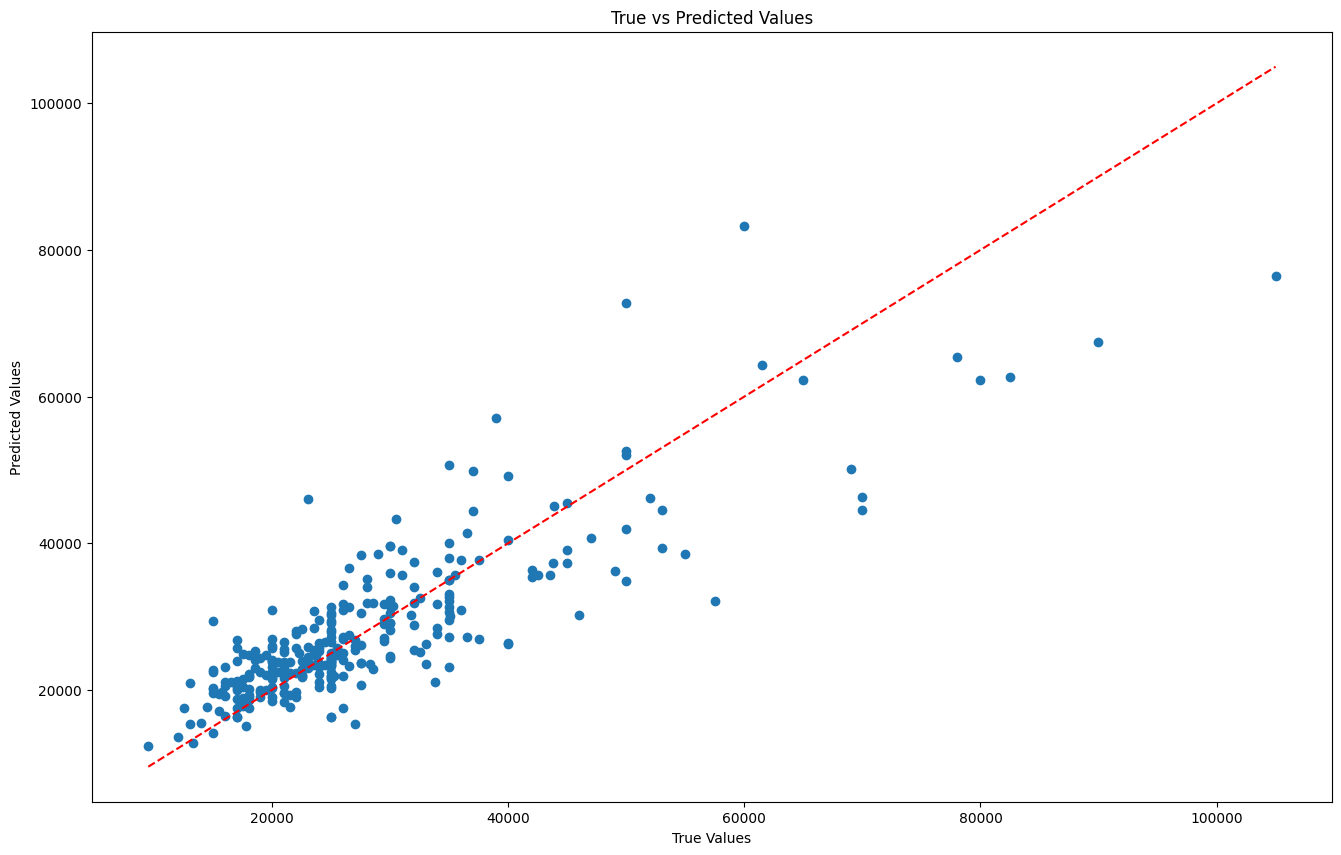

In [ ]:
kf = KFold(n_splits = 5,shuffle = True,random_state =  42)

splits = list(kf.split(X))
best_train_index,best_test_index = splits[1]

X_train,y_train = X.iloc[best_train_index],y.iloc[best_train_index]
X_test,y_test = X.iloc[best_test_index],y.iloc[best_test_index]

model = RandomForestRegressor(n_estimators = 100,bootstrap = True,max_depth = 30,max_features = 1.0,min_samples_leaf = 1,min_samples_split = 2)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

plt.figure(figsize = [16,10])
plt.scatter(y_test,y_pred)
plt.title("True vs Predicted Values")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],"r--")
plt.show()

# HyperParameter Tuning of GradientBoosting

In [ ]:
model = GradientBoostingRegressor(random_state=42)

kf = KFold(n_splits=5,shuffle = True,random_state = 42)

param_dist = {
    "n_estimators": np.arange(100, 1001, 100),      
    "learning_rate": np.logspace(-3, 0, 10),        
    "max_depth": np.arange(2, 11),                  
    "min_samples_split": np.arange(2, 21),          
    "min_samples_leaf": np.arange(1, 21),           
    "subsample": np.linspace(0.6, 1.0, 5),          
    "max_features": ["sqrt", "log2", None]          
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,              
    cv=kf,                   
    scoring="neg_root_mean_squared_error", 
    n_jobs=-1,              
    verbose=0,
    random_state=42
)
random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best RMSE Score:", random_search.best_score_)

Best Params: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 6, 'learning_rate': 0.046415888336127774}
Best RMSE Score: -7635.139915834376


In [ ]:
model = GradientBoostingRegressor(subsample = 0.9,n_estimators = 900,min_samples_split = 17,min_samples_leaf = 2,max_features = None,max_depth = 4,learning_rate = 0.01)

kf = KFold(n_splits = 5,shuffle = True,random_state =  42)

for train_index,test_index in kf.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))

    print("R2 Score: ",r2)
    print("RMSE Score: ",rmse)
    print("")

R2 Score:  0.6650011380194576
RMSE Score:  6934.21731946973

R2 Score:  0.7321557487831132
RMSE Score:  6763.447721521851

R2 Score:  0.600947001089374
RMSE Score:  8563.50096809585

R2 Score:  0.6398358920213016
RMSE Score:  7021.891762982084

R2 Score:  0.6899150397134475
RMSE Score:  7990.2471310028595



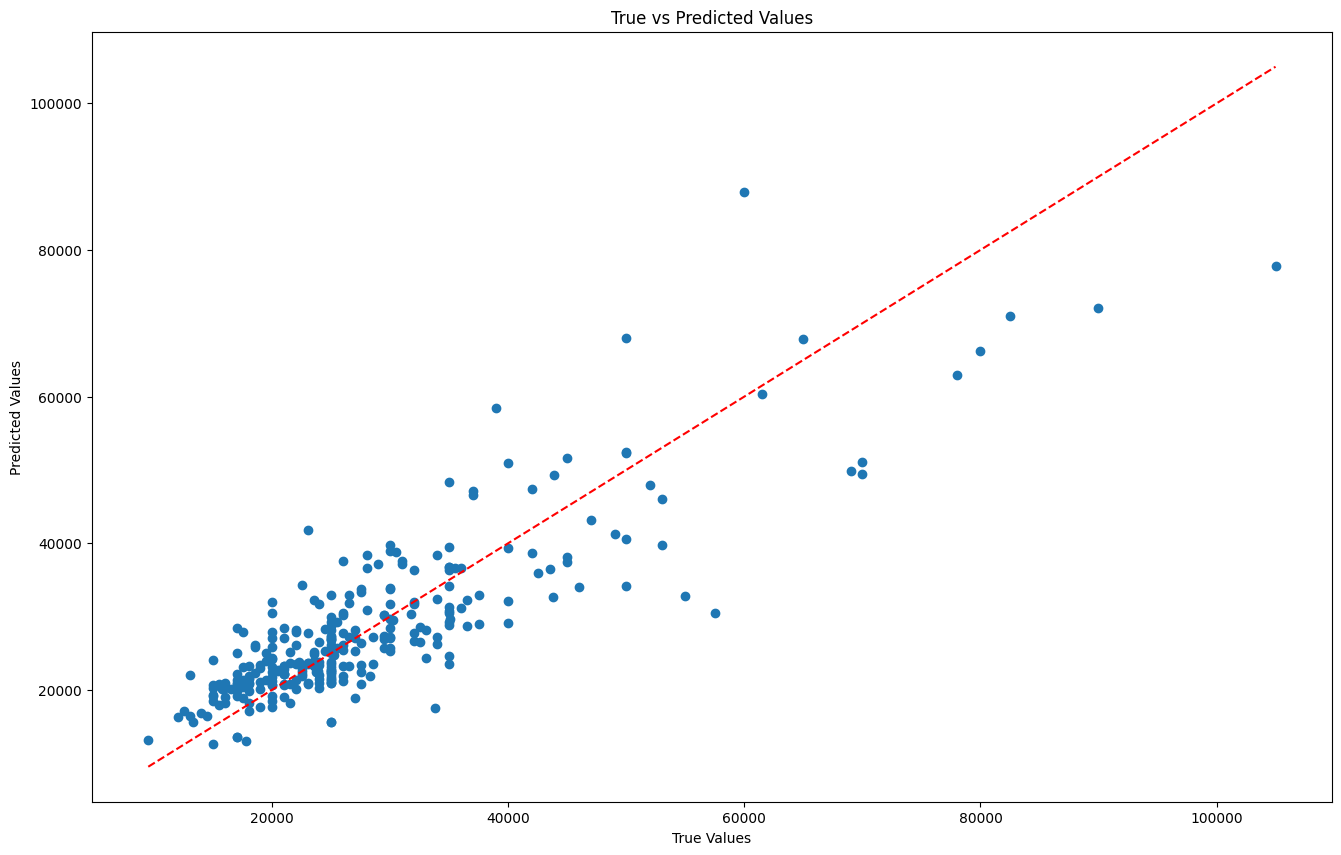

In [ ]:
kf = KFold(n_splits = 5,shuffle = True,random_state =  42)

splits = list(kf.split(X))
best_train_index,best_test_index = splits[1]

X_train,y_train = X.iloc[best_train_index],y.iloc[best_train_index]
X_test,y_test = X.iloc[best_test_index],y.iloc[best_test_index]

model = GradientBoostingRegressor(subsample = 0.9,n_estimators = 900,min_samples_split = 17,min_samples_leaf = 2,max_features = None,max_depth = 4,learning_rate = 0.01)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

plt.figure(figsize = [16,10])
plt.scatter(y_test,y_pred)
plt.title("True vs Predicted Values")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],"r--")
plt.show()


In [67]:
kf = KFold(n_splits = 5,shuffle = True,random_state =  42)

splits = list(kf.split(X))
best_train_index,best_test_index = splits[1]

X_train,y_train = X.iloc[best_train_index],y.iloc[best_train_index]
X_test,y_test = X.iloc[best_test_index],y.iloc[best_test_index]

model = GradientBoostingRegressor(subsample = 0.9,n_estimators = 900,min_samples_split = 17,min_samples_leaf = 2,max_features = None,max_depth = 4,learning_rate = 0.01)

model.fit(X_train,y_train)

best_model = model
joblib.dump(best_model,"ankara_house_rent.pkl")

['ankara_house_rent.pkl']

# Report

According RMSE and R2 scores,the best model is GradientBoostingRegressor with hyper parameter tuning.Even tough GradientBoosting and Random Forest models result are so close,GradientBoosting performs better with hyper parameter tuning.

There are several reasons why the results are not sufficient to use the model.

Firstly,the features that dataset has are not sufficient to train model.Because house prices depends on a lot of feature such as subway distance,age of building etc.And dataset has not these features.So if we want to train model truly we have to have a dataset that has more features.

Another reason is dataset does not contain sufficient data.And price scale or m2 scale does not distributed fairly.Therefore model does not train truly.

In conclusion, while Gradient Boosting shows potential, a richer and more balanced dataset is required for building a reliable price prediction model.